<a href="https://colab.research.google.com/github/mAliAytekin/ai-research-notes/blob/main/PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Solving coffee cooling problem with PINN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


### creating dataset


> ##### T(t) = T_room + (T0 - T_room) * exp(-k_true * t)


**T(t)**   -> temperature at t time

**T_room**-> temperatrure of the room, 25.0 °C

**T0**    -> begining temperature of coffee, 90.0 °C

**t**      -> time

**k_true** -> cooling coefficient, 0.1


In [2]:
T_room = 25.0
T0 = 90.0
k_true = 0.1

def true_temperature(t, T_room=25.0, T0=90.0, k_true=0.1):
    # analytic solving :  T(t) = T_room + (T0 - T_room)*exp(-k_true * t)
    return T_room + (T0 - T_room) * torch.exp(-k_true * t)


In [3]:
# time points
t_data = torch.linspace(0.0, 10.0, 11).unsqueeze(1).to(device)  # 0,1,2,...,10

# temperature points
T_data = true_temperature(t_data).to(device)

# extended test time
t_test =  torch.linspace(0.0, 10.0, 200).unsqueeze(1).to(device)

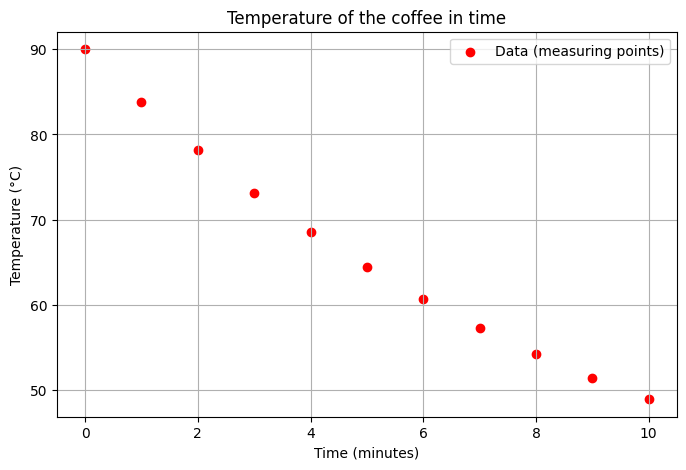

In [4]:
plt.figure(figsize=(8,5))
plt.scatter(t_data.cpu(), T_data.cpu(), label="Data (measuring points)", color="red")
plt.xlabel("Time (minutes)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.title("Temperature of the coffee in time")
plt.grid(True)
plt.show()


In [5]:
def plotting_nn(t_pred,t_true):
  plt.figure(figsize=(8,5))
  plt.scatter(t_data.cpu(), T_data.cpu(), label="Data (measuring points)", color="red")
  plt.plot(t_test.cpu(), t_true, label="True", linestyle="--")
  plt.plot(t_test.cpu(), t_pred, label="Prediction")
  plt.xlabel("Time (minutes)")
  plt.ylabel("Temperature (°C)")
  plt.legend()
  plt.title("Temperature of the coffee in time")
  plt.grid(True)
  plt.show()

### setting hyperparameters

In [6]:
num_epochs = 10000
lr = 1e-3
hidden_size = 32

### solving with MLP

In [7]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, t):
        return self.net(t)

In [8]:
model_nn = SimpleMLP().to(device)
optimizer = optim.Adam(model_nn.parameters(), lr)
criterion = nn.MSELoss()


for epoch in range(num_epochs):
    model_nn.train()
    optimizer.zero_grad()

    T_pred = model_nn(t_data)
    loss = criterion(T_pred, T_data)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 500 == 0:
        print(f"[NN] Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

[NN] Epoch 500/10000, Loss: 2406.292725
[NN] Epoch 1000/10000, Loss: 1292.752075
[NN] Epoch 1500/10000, Loss: 664.709229
[NN] Epoch 2000/10000, Loss: 349.889496
[NN] Epoch 2500/10000, Loss: 219.294296
[NN] Epoch 3000/10000, Loss: 178.167053
[NN] Epoch 3500/10000, Loss: 169.326157
[NN] Epoch 4000/10000, Loss: 168.176956
[NN] Epoch 4500/10000, Loss: 168.093506
[NN] Epoch 5000/10000, Loss: 168.085541
[NN] Epoch 5500/10000, Loss: 168.052551
[NN] Epoch 6000/10000, Loss: 28.998446
[NN] Epoch 6500/10000, Loss: 7.331476
[NN] Epoch 7000/10000, Loss: 2.428988
[NN] Epoch 7500/10000, Loss: 0.743797
[NN] Epoch 8000/10000, Loss: 0.162040
[NN] Epoch 8500/10000, Loss: 0.022705
[NN] Epoch 9000/10000, Loss: 0.001856
[NN] Epoch 9500/10000, Loss: 0.000120
[NN] Epoch 10000/10000, Loss: 0.000030


In [9]:
model_nn.eval()

with torch.no_grad():
    T_pred_mlp = model_nn(t_test).cpu()

T_true_mlp = true_temperature(t_test.cpu())

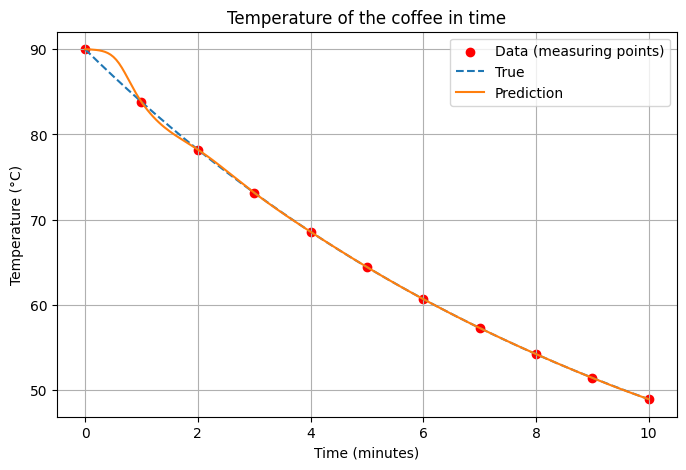

In [10]:
plotting_nn(T_pred_mlp,T_true_mlp)

### solving with PINN

In [11]:
class CoffeePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        # learning k parameter
        self.k = nn.Parameter(torch.tensor(0.05))

    def forward(self, t):
        # t shape: (N,1)
        return self.net(t)

In [12]:
model_pinn = CoffeePINN().to(device)
optimizer = optim.Adam(model_pinn.parameters(), lr)

In [13]:
t_phys = torch.linspace(0.0, 10.0, 100).unsqueeze(1).to(device)
t_phys.requires_grad_(True)

tensor([[ 0.0000],
        [ 0.1010],
        [ 0.2020],
        [ 0.3030],
        [ 0.4040],
        [ 0.5051],
        [ 0.6061],
        [ 0.7071],
        [ 0.8081],
        [ 0.9091],
        [ 1.0101],
        [ 1.1111],
        [ 1.2121],
        [ 1.3131],
        [ 1.4141],
        [ 1.5152],
        [ 1.6162],
        [ 1.7172],
        [ 1.8182],
        [ 1.9192],
        [ 2.0202],
        [ 2.1212],
        [ 2.2222],
        [ 2.3232],
        [ 2.4242],
        [ 2.5253],
        [ 2.6263],
        [ 2.7273],
        [ 2.8283],
        [ 2.9293],
        [ 3.0303],
        [ 3.1313],
        [ 3.2323],
        [ 3.3333],
        [ 3.4343],
        [ 3.5354],
        [ 3.6364],
        [ 3.7374],
        [ 3.8384],
        [ 3.9394],
        [ 4.0404],
        [ 4.1414],
        [ 4.2424],
        [ 4.3434],
        [ 4.4444],
        [ 4.5455],
        [ 4.6465],
        [ 4.7475],
        [ 4.8485],
        [ 4.9495],
        [ 5.0505],
        [ 5.1515],
        [ 5.

In [14]:
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # --- Data loss ---
    T_pred_data = model_pinn(t_data)
    loss_data = torch.mean((T_pred_data - T_data)**2)

    # --- Physical loss (ODE residual) ---
    T_pred_phys = model_pinn(t_phys)             # T(t)
    dTdt = torch.autograd.grad(
        T_pred_phys, t_phys,
        grad_outputs=torch.ones_like(T_pred_phys),
        create_graph=True
    )[0]  # dT/dt

    # ODE: dT/dt + k*(T - T_room) = 0
    k = model_pinn.k
    residual = dTdt + k * (T_pred_phys - T_room)
    loss_phys = torch.mean(residual**2)

    # --- Begining loss T(0) ≈ T0 ---
    t0 = torch.zeros((1,1), device=device, requires_grad=True)
    T0_pred = model_pinn(t0)
    loss_ic = torch.mean((T0_pred - T0)**2)

    # Total loss
    loss = loss_data + loss_phys + loss_ic

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}  "
              f"Loss: {loss.item():.6f}  "
              f"k: {model_pinn.k.item():.4f}")

Epoch 500/10000  Loss: 7067.226562  k: 0.0002
Epoch 1000/10000  Loss: 4165.687012  k: -0.0001
Epoch 1500/10000  Loss: 2359.604980  k: -0.0000
Epoch 2000/10000  Loss: 1311.111694  k: -0.0000
Epoch 2500/10000  Loss: 772.561401  k: -0.0000
Epoch 3000/10000  Loss: 533.146606  k: 0.0019
Epoch 3500/10000  Loss: 165.236053  k: 0.0648
Epoch 4000/10000  Loss: 56.714348  k: 0.0775
Epoch 4500/10000  Loss: 15.738253  k: 0.0871
Epoch 5000/10000  Loss: 3.430974  k: 0.0936
Epoch 5500/10000  Loss: 0.756310  k: 0.0970
Epoch 6000/10000  Loss: 0.232844  k: 0.0985
Epoch 6500/10000  Loss: 0.094303  k: 0.0991
Epoch 7000/10000  Loss: 0.043711  k: 0.0994
Epoch 7500/10000  Loss: 0.021439  k: 0.0996
Epoch 8000/10000  Loss: 0.010775  k: 0.0997
Epoch 8500/10000  Loss: 0.005608  k: 0.0998
Epoch 9000/10000  Loss: 0.003112  k: 0.0999
Epoch 9500/10000  Loss: 0.001858  k: 0.0999
Epoch 10000/10000  Loss: 0.001191  k: 0.0999


In [15]:
model_pinn.eval()

with torch.no_grad():
    T_pred_pinn = model_pinn(t_test).cpu()

T_true_pinn = true_temperature(t_test.cpu())

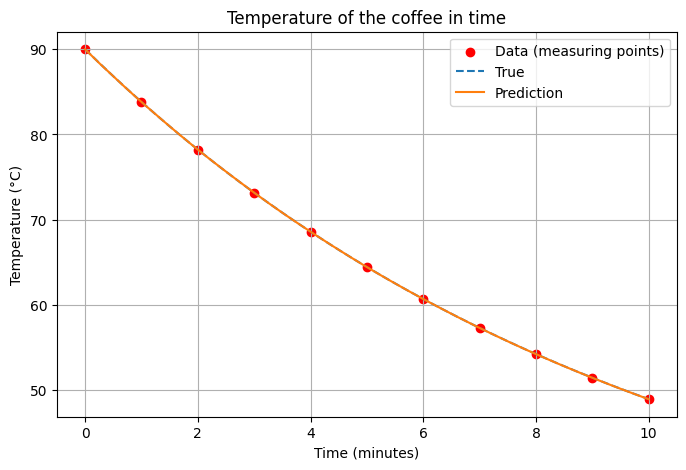

In [16]:
plotting_nn(T_pred_pinn,T_true_pinn)

In [17]:
print("\n--- More Precise Comparison ---")

mse_mlp = torch.mean((T_pred_mlp - T_true_mlp)**2).item()
print(f"MLP Predicition - MSE: {mse_mlp:.6f}")

mse_pinn = torch.mean((T_pred_pinn - T_true_pinn)**2).item()
print(f"PINN Prediction - MSE: {mse_pinn:.6f}")

# PINN residual
t_phys_eval = t_test.clone().detach().requires_grad_(True)
T_pred_phys_eval = model_pinn(t_phys_eval)
dTdt_eval = torch.autograd.grad(
    T_pred_phys_eval,
    t_phys_eval,
    grad_outputs=torch.ones_like(T_pred_phys_eval),
    create_graph=True
)[0]

k_pinn_learned = model_pinn.k.item()
residual_eval = dTdt_eval + k_pinn_learned * (T_pred_phys_eval - T_room)
mean_residual_pinn = torch.mean(torch.abs(residual_eval)).item()
print(f"Average Physical Residual for PINN: {mean_residual_pinn:.6f}")

print(f"True k coefficient: {k_true:.4f}")
print(f"The k value learned by PINN: {model_pinn.k.item():.4f}")


--- More Precise Comparison ---
MLP Predicition - MSE: 0.251072
PINN Prediction - MSE: 0.000040
Average Physical Residual for PINN: 0.016288
True k coefficient: 0.1000
The k value learned by PINN: 0.0999


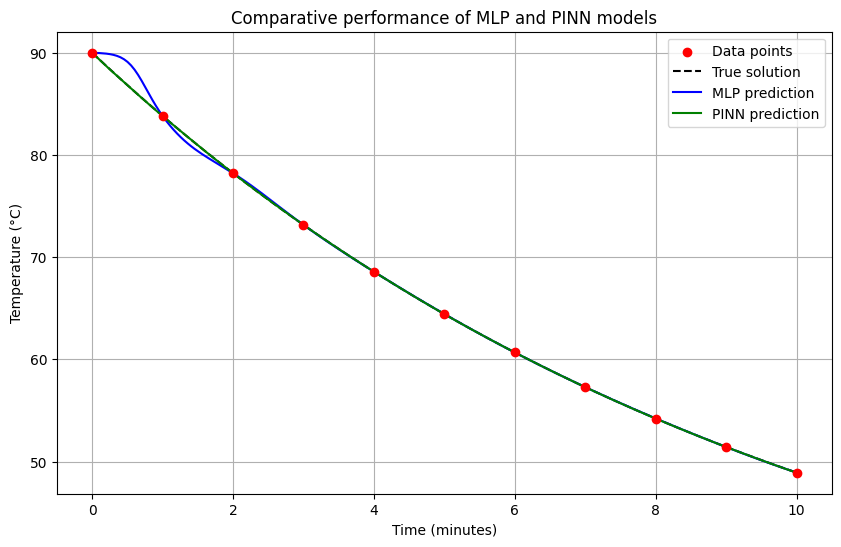

Final loss for MLP: 0.001191
Final loss for PINN: 0.001191
k value learned by PINN: 0.0999


In [18]:
plt.figure(figsize=(10,6))
plt.scatter(t_data.cpu(), T_data.cpu(), label="Data points", color="red", zorder=5)
plt.plot(t_test.cpu(), T_true_pinn, label="True solution", linestyle="--", color="black")
plt.plot(t_test.cpu(), T_pred_mlp, label="MLP prediction", color="blue")
plt.plot(t_test.cpu(), T_pred_pinn, label="PINN prediction", color="green")
plt.xlabel("Time (minutes)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.title("Comparative performance of MLP and PINN models")
plt.grid(True)
plt.show()

print(f"Final loss for MLP: {loss.item():.6f}")  # Assuming 'loss' from MLP training is the last stored value
print(f"Final loss for PINN: {loss_data.item() + loss_phys.item() + loss_ic.item():.6f}")  # Summing PINN losses for comparison
print(f"k value learned by PINN: {model_pinn.k.item():.4f}")
